# Thresholding Group Analyses

> Adapted from [DartBrains](https://dartbrains.org/) by Luke Chang (© Luke Chang, supported by NSF CAREER Award 1848370), used under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). **Changes made:** trimmed to the exercise sections, setup code reduced to the cells the exercises depend on, display-only calls removed. Exercise solutions are my own work. This notebook is therefore also distributed under CC BY-SA 4.0. No endorsement by the original author is implied.


## Setup


In [ ]:
%matplotlib inline

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.data import Brain_Data
from nltools.simulator import SimulateGrid
from IPython.display import Image


/opt/conda/lib/python3.9/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


## Exercises

### Exercise 1. Bonferroni Correction Simulation

In [ ]:
from tqdm import tqdm
grid_width = 100
threshold = .05/(grid_width**2)
signal_width = 10
signal_amplitude = np.arange(1,3,0.2)

sigRecov = []
fpr = []
minFound = False
for SIG in tqdm(signal_amplitude):
    
    simulation = SimulateGrid(signal_amplitude=SIG, signal_width=signal_width, grid_width=grid_width, n_subjects=20)
    simulation.plot_grid_simulation(threshold=threshold, threshold_type='p', n_simulations=100)
    plt.close()
    sigRecov.append(simulation.tp_percent)
    fpr.append(simulation.fpr)
    if not minFound and simulation.tp_percent == 1:
        minAmp = SIG
        minFound = True
        print(f'minimum signal amplitude for 100% recovery = {minAmp}')
    

 70%|███████   | 7/10 [00:20<00:08,  2.94s/it]

minimum signal amplitude for 100% recovery = 2.1999999999999997


100%|██████████| 10/10 [00:29<00:00,  2.92s/it]


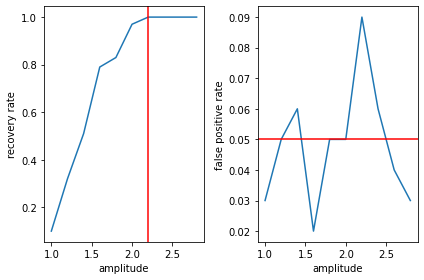

In [ ]:
f,ax = plt.subplots(nrows=1,ncols=2)
ax[0].plot(signal_amplitude,sigRecov)
ax[0].axvline(minAmp,color='r')
ax[0].set_xlabel('amplitude')
ax[0].set_ylabel('recovery rate')

ax[1].plot(signal_amplitude,fpr)
ax[1].axhline(0.05,color='r')
ax[1].set_xlabel('amplitude')
ax[1].set_ylabel('false positive rate')

plt.tight_layout()

### Exercise 2. Which regions are more involved with visual compared to auditory sensory processing?


In [ ]:
# grab code from Module 10!

import bids
from tqdm import tqdm

# set data directory
data_dir = '/home/jovyan/shared/PSYCH60-22S/data/localizer'

# get bids layout for localizer project
layout = bids.BIDSLayout(data_dir + '/derivatives/fmriprep/', config=['bids','derivatives'])

# get subject list and sort it
subList = layout.get(target='subject', return_type='id') # get subject list
subList.sort()

# define file strings
vidString = 'video'
checkString = 'checkerboard'
audString = 'audio'

# loop through each subject
vva = [] # initialize contrast vector
for SUB in tqdm(subList):

    # get beta files
    vid_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{vidString}*nii.gz'))
    check_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{checkString}*nii.gz'))
    aud_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{audString}*nii.gz'))
    
    # combine video and checkerboard lists
    vList = vid_file_list + check_file_list
    
    # load visual task betas
    vData = Brain_Data(vList).mean()
    
    # load auditory task betas
    aData = Brain_Data(aud_file_list).mean()
    
    # compute subject-level contrast
    vva.append(vData - aData)
    
# combine all subject-level contrasts into one Brain_Data object
vva_con = Brain_Data(vva)


100%|██████████| 28/28 [07:58<00:00, 17.10s/it]


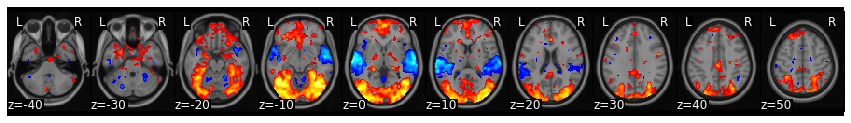

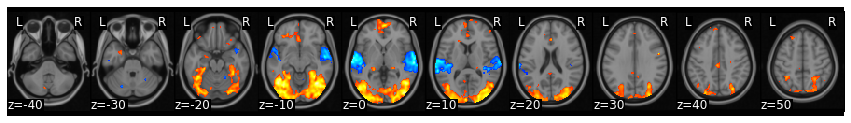

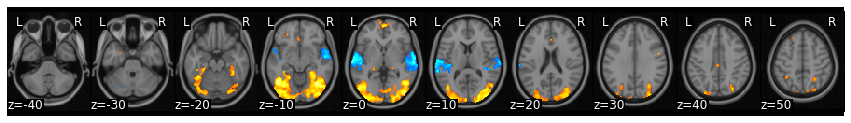

In [ ]:
# threshold at different levels

for THRESH in [0.05, 0.005, 0.001]:
    
    # run t-test
    stats = vva_con.ttest(threshold_dict={'unc':THRESH})
    
    # plot
    stats['thr_t'].plot()
    
    # write
    stats['thr_t'].write(f'Module_11_exercise_1_uncorrected_{THRESH}.nii.gz')
    
    

### Exercise 3. Which regions are more involved in processing numbers compared to words?

In [ ]:
# grab code from module 10 exercise 2

# define file strings
compString = 'computation'
sentString = 'sentence'

# loop through each subject
cvs = [] # initialize contrast vector
for SUB in tqdm(subList):

    # get beta files
    comp_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{compString}*nii.gz'))
    sent_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{sentString}*nii.gz'))
    
    # load computation task betas
    cData = Brain_Data(comp_file_list).mean()
    
    # load sentence task betas
    sData = Brain_Data(sent_file_list).mean()
    
    # compute subject-level contrastb
    cvs.append(cData - sData)
    
# get contrasts in one brain data object
cvs_con = Brain_Data(cvs)


100%|██████████| 28/28 [03:12<00:00,  6.88s/it]


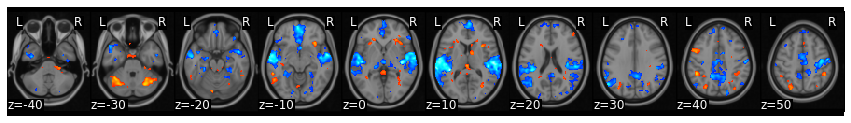

In [ ]:
# run fdr corrected t-test
stats = cvs_con.ttest(threshold_dict={'fdr':0.05})
stats['thr_t'].plot()
stats['thr_t'].write(f'Module_11_exercise_2_fdr_{0.05}.nii.gz')